# Pernambuco no Comércio Exterior (2024-2026): Análise Detalhada de Exportações e Importações

## Sumário Executivo

Este notebook apresenta uma análise exploratória aprofundada do comércio exterior de Pernambuco entre 2024 e 2026, utilizando dados oficiais da base de exportações e importações por município.

### Objetivos da Análise

1. **Dimensionar** o volume e valor do comércio exterior pernambucano
2. **Identificar** padrões temporais e sazonalidade nas operações
3. **Mapear** a distribuição geográfica das atividades comerciais
4. **Caracterizar** os principais parceiros comerciais e blocos econômicos
5. **Analisar** a composição da pauta de exportação e importação
6. **Detectar** concentrações de risco e oportunidades de diversificação

### Estrutura do Notebook

O notebook está organizado em 8 seções principais:

1. **Setup e Carregamento** - Configuração do ambiente e preparação dos dados
2. **Qualidade dos Dados** - Validação de cobertura e integridade
3. **Painel Executivo** - Indicadores agregados e evolução temporal
4. **Geografia Econômica** - Análise municipal e territorial
5. **Parceiros Internacionais** - Países e blocos econômicos
6. **Estrutura da Pauta** - Produtos e setores (classificação SH2)
7. **Storytelling Analítico** - Síntese narrativa dos insights
8. **Recomendações** - Próximos passos para aprofundamento

### Fonte de Dados

**Arquivo:** `V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv`  
**Extração:** 03 de março de 2026  
**Cobertura:** Janeiro/2024 a Fevereiro/2026 (verificar data efetiva na seção 2)

---

## Como Usar Este Notebook

**Para executivos e gestores públicos:**  
Concentre-se nas seções 3 (Painel Executivo) e 7 (Storytelling Analítico) para uma visão estratégica rápida.

**Para analistas técnicos:**  
Todas as seções contêm metodologia detalhada e podem ser adaptadas para análises customizadas.

**Para desenvolvedores:**  
O código está estruturado de forma modular, permitindo reutilização das funções em outros contextos.

---

## 1. Setup e Carregamento de Dados

Esta seção prepara o ambiente de análise e carrega os dados com tratamento adequado de qualidade e consistência.

### 1.1 Importação de Bibliotecas

Utilizamos as principais bibliotecas do ecossistema Python para análise de dados:

- **pandas**: manipulação e análise de dados tabulares
- **numpy**: operações numéricas e arrays
- **matplotlib/seaborn**: visualizações e gráficos
- **pathlib**: gerenciamento de caminhos de arquivos

In [355]:
%matplotlib inline

from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Suprime warnings desnecessários para melhor legibilidade
warnings.filterwarnings("ignore")

# Configuração de estilo visual para gráficos
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# Configuração de display do pandas para melhor visualização
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


### 1.2 Funções Utilitárias

Definimos funções auxiliares para:
1. Localizar o arquivo de dados em diferentes estruturas de diretório
2. Normalizar textos (remover caracteres especiais)
3. Formatar valores monetários no padrão brasileiro

In [356]:
def resolve_data_path() -> Path:
    """
    Procura o arquivo de dados em múltiplos caminhos possíveis.
    
    Returns:
        Path: Caminho absoluto para o arquivo de dados
        
    Raises:
        FileNotFoundError: Se o arquivo não for encontrado em nenhum caminho
    """
    candidates = [
        Path("data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv"),
        Path("../../../data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv"),
        Path("../../data/pe/comex/V_EXPORTACAO_E IMPORTACAO_POR MUNICIPIO_2024-01_2026-12_DT20260303.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError("Arquivo de dados não encontrado nos caminhos esperados.")


# Mapeamento de strings de mês para números
MONTH_MAP = {
    "01": 1, "02": 2, "03": 3, "04": 4, "05": 5, "06": 6,
    "07": 7, "08": 8, "09": 9, "10": 10, "11": 11, "12": 12,
}


def clean_text(s: pd.Series) -> pd.Series:
    """
    Remove caracteres especiais e normaliza texto de uma coluna pandas.
    
    Args:
        s: Série pandas com texto para limpar
        
    Returns:
        Série pandas com texto normalizado
    """
    return (
        s.astype("string")
         .str.replace("\r", "", regex=False)
         .str.replace("\xa0", " ", regex=False)
         .str.strip()
    )


def br_money(x: float) -> str:
    """
    Formata valores monetários no padrão brasileiro com siglas (mi, bi).
    
    Args:
        x: Valor numérico em US$
        
    Returns:
        String formatada (ex: "US$ 1,5 bi" ou "US$ 250,3 mi")
    """
    if pd.isna(x):
        return "-"
    if abs(x) >= 1e9:
        return f"US$ {x/1e9:,.2f} bi".replace(",", "X").replace(".", ",").replace("X", ".")
    if abs(x) >= 1e6:
        return f"US$ {x/1e6:,.1f} mi".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"US$ {x:,.0f}".replace(",", ".")

print("Funções utilitárias definidas.")

Funções utilitárias definidas.


### 1.3 Função de Carregamento e Preparação dos Dados

A função `load_comex()` realiza:
- Leitura do CSV com encoding adequado
- Limpeza de caracteres especiais em todas as colunas de texto
- Conversão de tipos de dados (numéricos, datas)
- Extração do número do mês a partir da coluna textual
- Remoção de registros inválidos ou incompletos

In [357]:
def load_comex(path: Path) -> pd.DataFrame:
    """
    Carrega e processa o arquivo de dados de comércio exterior.
    
    Etapas de processamento:
    1. Leitura do CSV com delimitador ';' e encoding UTF-8 com BOM
    2. Limpeza de caracteres especiais em todas as colunas de texto
    3. Conversão de colunas numéricas (Ano, Valor, Peso)
    4. Extração e conversão do número do mês
    5. Criação da coluna de data completa
    6. Remoção de registros com campos essenciais faltantes
    
    Args:
        path: Caminho para o arquivo CSV
        
    Returns:
        DataFrame pandas com os dados processados
    """
    # Leitura inicial mantendo tudo como string
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig", dtype=str)

    # Limpeza de texto em todas as colunas
    for col in df.columns:
        df[col] = clean_text(df[col])

    # Conversão de tipos numéricos
    df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce").astype("Int64")
    df["Valor US$ FOB"] = pd.to_numeric(df["Valor US$ FOB"], errors="coerce")
    df["Quilograma Líquido"] = pd.to_numeric(df["Quilograma Líquido"], errors="coerce")

    # Extração do número do mês (formato original: "01. Janeiro")
    df["MesNum"] = df["Mês"].str.extract(r"^(\d{2})")[0].map(MONTH_MAP)
    
    # Criação da coluna de data
    df["Data"] = pd.to_datetime(
        dict(year=df["Ano"].astype("float"), month=df["MesNum"].astype("float"), day=1),
        errors="coerce"
    )

    # Remoção de linhas com campos essenciais faltantes
    df = df.dropna(subset=["Fluxo", "Ano", "MesNum", "Valor US$ FOB"])

    return df

print("Função de carregamento definida.")

Função de carregamento definida.


### 1.4 Carregamento e Tratamento de Deduplicação

**Importante:** O arquivo original contém múltiplas classificações de bloco econômico para a mesma transação comercial, causando duplicidade analítica.

**Estratégia de tratamento:**
1. **DataFrame principal (`df`)**: Remove duplicatas ignorando a coluna "Bloco Econômico" para cálculos de totais (valores e pesos)
2. **DataFrame para blocos (`df_block`)**: Mantém apenas um bloco por transação, priorizando blocos específicos sobre regiões genéricas

Esta abordagem evita dupla contagem nos valores totais enquanto permite análise consistente por blocos.

In [358]:
# Localiza e carrega o arquivo de dados
DATA_PATH = resolve_data_path()
print(f"Arquivo encontrado: {DATA_PATH}")
print(f"Tamanho do arquivo: {DATA_PATH.stat().st_size / 1024 / 1024:.1f} MB\n")

# Carrega dados brutos
print("Carregando dados...")
df_raw = load_comex(DATA_PATH)
print(f"✓ Linhas carregadas: {len(df_raw):,}\n")

# Tratamento de deduplicação
print("Aplicando tratamento de deduplicação...")

# DataFrame principal: ignora 'Bloco Econômico' para evitar dupla contagem
key_cols = [c for c in df_raw.columns if c != "Bloco Econômico"]
df = df_raw.drop_duplicates(subset=key_cols).copy()
print(f"✓ DataFrame principal (totais): {len(df):,} linhas")

# DataFrame para análise de blocos: prioriza blocos específicos
global_regions = {
    "África", "Europa", "Oceania", "América do Sul", "América do Norte",
    "Oriente Médio", "América Central e Caribe", "Ásia (Exclusive Oriente Médio)",
}

df_block = df_raw.copy()
df_block["is_global_region"] = df_block["Bloco Econômico"].isin(global_regions)
df_block = (
    df_block
    .sort_values(["is_global_region", "Bloco Econômico"], ascending=[True, True])
    .drop_duplicates(subset=key_cols, keep="first")
    .drop(columns="is_global_region")
)
print(f"✓ DataFrame para blocos: {len(df_block):,} linhas\n")

print("="*60)
print("DADOS CARREGADOS E PRONTOS PARA ANÁLISE")
print("="*60)

✓ DataFrame para blocos: 81,413 linhas

DADOS CARREGADOS E PRONTOS PARA ANÁLISE


---

## 2. Qualidade e Escopo dos Dados

Antes de iniciar as análises, é fundamental validar:
- Cobertura temporal efetiva dos dados
- Distribuição de registros por fluxo (Exportação/Importação)
- Integridade das variáveis essenciais (valores faltantes)

### 2.1 Visão Geral da Base

In [359]:
# Informações básicas do dataset
print("INFORMAÇÕES GERAIS DO DATASET")
print("="*60)
print(f"Total de registros: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")
print(f"\nPeríodo de cobertura:")
print(f"  Data inicial: {df['Data'].min():%d/%m/%Y}")
print(f"  Data final: {df['Data'].max():%d/%m/%Y}")
print(f"  Total de meses: {df['Data'].nunique()}")
print("\n" + "="*60)

INFORMAÇÕES GERAIS DO DATASET
Total de registros: 81,413
Total de colunas: 17

Período de cobertura:
  Data inicial: 01/01/2024
  Data final: 01/01/2026
  Total de meses: 25



In [360]:
# Distribuição de registros por fluxo
flux_counts = (
    df["Fluxo"]
    .value_counts()
    .rename_axis("Fluxo")
    .reset_index(name="Registros")
)
flux_counts["Percentual"] = (flux_counts["Registros"] / flux_counts["Registros"].sum() * 100).round(1)

print("\nDISTRIBUIÇÃO POR FLUXO")
print("="*60)
display(flux_counts)

# Estatísticas de valor por fluxo
valor_stats = (
    df.groupby("Fluxo")["Valor US$ FOB"]
    .agg(["sum", "mean", "median", "min", "max"])
    .rename(columns={
        "sum": "Total",
        "mean": "Média",
        "median": "Mediana",
        "min": "Mínimo",
        "max": "Máximo"
    })
)

print("\nESTATÍSTICAS DE VALOR (US$ FOB) POR FLUXO")
print("="*60)
display(valor_stats)

,Total,Média,Mediana,Mínimo,Máximo
Fluxo,,,,,
Exportação,4629012583,236802.362543,333.0,0,70185370
Importação,15197990990,245663.800048,10923.0,0,314087148


### 2.2 Análise de Valores Faltantes

Verificação da integridade dos campos essenciais para as análises.

In [361]:
# Análise de valores faltantes nas colunas principais
key_columns = [
    "Fluxo", "Ano", "Mês", "Data", "País", "Município",
    "Código SH2", "Descrição SH2", "Valor US$ FOB", "Quilograma Líquido"
]

missing_analysis = (
    df[key_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame(name="% Valores Faltantes")
)

print("ANÁLISE DE VALORES FALTANTES")
print("="*60)
display(missing_analysis)

if missing_analysis["% Valores Faltantes"].max() == 0:
    print("\n✓ Excelente: Nenhum valor faltante nas colunas essenciais!")
else:
    print(f"\n⚠ Atenção: Campos com valores faltantes detectados.")


✓ Excelente: Nenhum valor faltante nas colunas essenciais!


### 2.3 Cobertura Temporal Detalhada

Verificação mês a mês da completude dos dados.

In [362]:
# Cobertura mensal
coverage = (
    df.groupby(["Ano", "MesNum"], as_index=False)
    .agg(
        valor_total=("Valor US$ FOB", "sum"),
        n_registros=("Fluxo", "size"),
        n_municipios=("Município", "nunique"),
        n_paises=("País", "nunique")
    )
    .sort_values(["Ano", "MesNum"])
)

coverage["Ano-Mês"] = coverage["Ano"].astype(str) + "-" + coverage["MesNum"].astype(str).str.zfill(2)

print("COBERTURA TEMPORAL DETALHADA")
print("="*60)
display(coverage[["Ano-Mês", "n_registros", "n_municipios", "n_paises", "valor_total"]].tail(12))

print(f"\nTotal de meses na base: {len(coverage)}")
print(f"Período efetivo: {coverage['Ano-Mês'].iloc[0]} a {coverage['Ano-Mês'].iloc[-1]}")


Total de meses na base: 25
Período efetivo: 2024-01 a 2026-01


---

## 3. Painel Executivo: Indicadores Agregados

Esta seção apresenta os principais indicadores do comércio exterior de Pernambuco:
- Valores totais de exportação e importação
- Saldo comercial
- Evolução temporal (mensal e anual)
- Comparação Year-over-Year (YoY)

### 3.1 Indicadores Principais

In [363]:
# Cálculo dos KPIs principais
kpi = (
    df.groupby("Fluxo", as_index=False)["Valor US$ FOB"]
    .sum()
    .rename(columns={"Valor US$ FOB": "valor"})
)

exp_total = kpi.loc[kpi["Fluxo"].eq("Exportação"), "valor"].sum()
imp_total = kpi.loc[kpi["Fluxo"].eq("Importação"), "valor"].sum()
saldo_total = exp_total - imp_total
corrente_comercio = exp_total + imp_total

# DataFrame de resumo
kpi_summary = pd.DataFrame({
    "Indicador": [
        "Exportações acumuladas",
        "Importações acumuladas",
        "Saldo comercial",
        "Corrente de comércio",
        "Taxa de cobertura (Exp/Imp)",
    ],
    "Valor": [
        br_money(exp_total),
        br_money(imp_total),
        br_money(saldo_total),
        br_money(corrente_comercio),
        f"{(exp_total/imp_total*100):.1f}%" if imp_total > 0 else "-"
    ]
})

print("INDICADORES PRINCIPAIS DO COMÉRCIO EXTERIOR")
print("="*60)
display(kpi_summary)

# Interpretação
if saldo_total > 0:
    print(f"\n✓ Superávit comercial de {br_money(saldo_total)}")
else:
    print(f"\n⚠ Déficit comercial de {br_money(abs(saldo_total))}")


⚠ Déficit comercial de US$ 10,57 bi


### 3.2 Evolução Temporal Mensal

In [364]:
# Série temporal mensal
monthly = (
    df.groupby(["Data", "Fluxo"], as_index=False)["Valor US$ FOB"]
    .sum()
    .pivot(index="Data", columns="Fluxo", values="Valor US$ FOB")
    .fillna(0)
    .rename_axis(None, axis=1)
)

# Garante que ambas as colunas existam
if "Exportação" not in monthly.columns:
    monthly["Exportação"] = 0
if "Importação" not in monthly.columns:
    monthly["Importação"] = 0

monthly["Saldo"] = monthly["Exportação"] - monthly["Importação"]
monthly = monthly.reset_index()

print("SÉRIE TEMPORAL MENSAL (últimos 12 meses)")
print("="*60)
display(monthly.tail(12))

,Data,Exportação,Importação,Saldo
13,2025-02-01,210672017,661525396,-450853379
14,2025-03-01,180258662,544255794,-363997132
15,2025-04-01,253812490,544272282,-290459792
16,2025-05-01,164629797,610375244,-445745447
17,2025-06-01,223396643,558911726,-335515083
18,2025-07-01,217925958,637468863,-419542905
19,2025-08-01,119198753,512234862,-393036109
20,2025-09-01,176014616,581335244,-405320628
21,2025-10-01,239278104,565507152,-326229048
22,2025-11-01,204027326,587915506,-383888180


### 3.3 Evolução Anual e Comparação YTD (Year-to-Date)

**Análise anual completa** e **comparação YTD** (recorte comparável de meses entre anos).

In [365]:
# Agregação anual completa
annual = (
    df.groupby(["Ano", "Fluxo"], as_index=False)["Valor US$ FOB"]
    .sum()
    .pivot(index="Ano", columns="Fluxo", values="Valor US$ FOB")
    .fillna(0)
    .rename_axis(None, axis=1)
    .reset_index()
)
if "Exportação" not in annual.columns:
    annual["Exportação"] = 0
if "Importação" not in annual.columns:
    annual["Importação"] = 0
annual["Saldo"] = annual["Exportação"] - annual["Importação"]

print("EVOLUÇÃO ANUAL COMPLETA")
print("="*60)
display(annual)

# YTD comparável: usa os meses efetivamente disponíveis do último ano
last_year = int(df["Ano"].max())
months_last_year = sorted(df.loc[df["Ano"].eq(last_year), "MesNum"].dropna().unique().tolist())

print(f"\nMeses disponíveis em {last_year}: {months_last_year}")
print("Calculando YTD comparável para todos os anos usando esses meses...\n")

ytd = (
    df[df["MesNum"].isin(months_last_year)]
    .groupby(["Ano", "Fluxo"], as_index=False)["Valor US$ FOB"]
    .sum()
    .pivot(index="Ano", columns="Fluxo", values="Valor US$ FOB")
    .fillna(0)
    .rename_axis(None, axis=1)
    .reset_index()
)
if "Exportação" not in ytd.columns:
    ytd["Exportação"] = 0
if "Importação" not in ytd.columns:
    ytd["Importação"] = 0
ytd["Saldo"] = ytd["Exportação"] - ytd["Importação"]

print("COMPARAÇÃO YTD (YEAR-TO-DATE)")
print("="*60)
display(ytd)

# Cálculo de variação YoY
if len(ytd) >= 2:
    ytd_sorted = ytd.sort_values("Ano")
    prev_year = ytd_sorted.iloc[-2]
    curr_year = ytd_sorted.iloc[-1]
    
    exp_growth = ((curr_year["Exportação"] / prev_year["Exportação"] - 1) * 100) if prev_year["Exportação"] > 0 else 0
    imp_growth = ((curr_year["Importação"] / prev_year["Importação"] - 1) * 100) if prev_year["Importação"] > 0 else 0
    
    print(f"\nVARIAÇÃO YoY ({int(prev_year['Ano'])} → {int(curr_year['Ano'])})")
    print("="*60)
    print(f"Exportações: {exp_growth:+.1f}%")
    print(f"Importações: {imp_growth:+.1f}%")


VARIAÇÃO YoY (2025 → 2026)
Exportações: -26.0%
Importações: -21.3%


### 3.3 Visualização da Evolução Temporal

Os gráficos abaixo ilustram:
1. **Evolução mensal** de exportações e importações
2. **Saldo mensal** (verde para superávit, laranja para déficit)

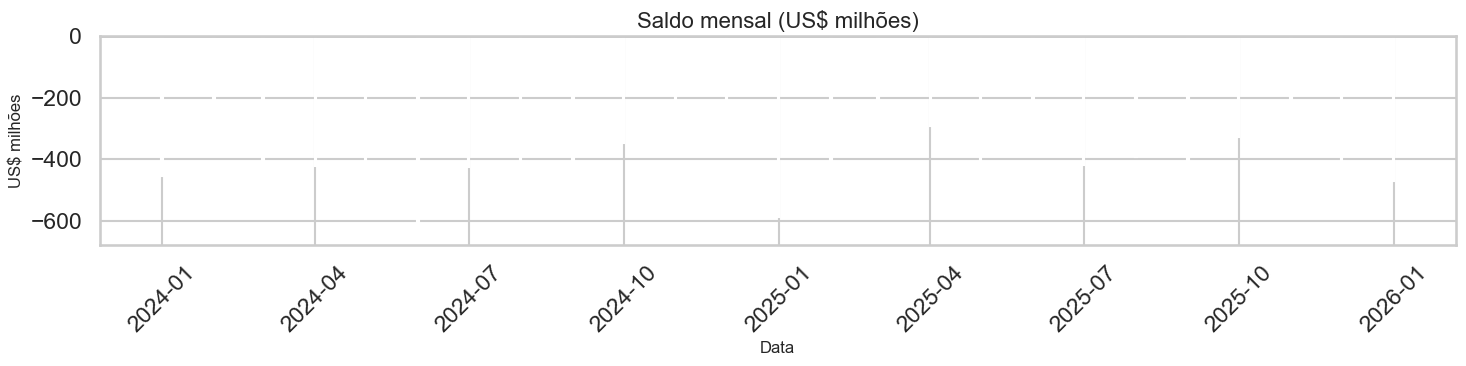

In [366]:

fig, ax = plt.subplots(1, 1, figsize=(15, 6))
ax.plot(monthly["Data"], monthly["Exportação"] / 1e6, marker="o", linewidth=2, label="Exportação")
ax.plot(monthly["Data"], monthly["Importação"] / 1e6, marker="o", linewidth=2, label="Importação")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Evolução mensal: Exportações vs Importações (US$ milhões)")
ax.set_ylabel("US$ milhões")
ax.set_xlabel("Data")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(15, 4))
colors = np.where(monthly["Saldo"] >= 0, "#1b9e77", "#d95f02")
ax.bar(monthly["Data"], monthly["Saldo"] / 1e6, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Saldo mensal (US$ milhões)")
ax.set_ylabel("US$ milhões")
ax.set_xlabel("Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Interpretação dos Gráficos

**Pontos de atenção:**
- Verificar se há tendência de crescimento ou queda
- Identificar sazonalidade nas operações
- Analisar a persistência de déficits comerciais
- Avaliar volatilidade mensal

---

## 4. Geografia Econômica: Municípios Protagonistas

Nesta seção identificamos:
- Quais municípios lideram as exportações e importações
- Grau de concentração territorial das atividades
- Diversificação da pauta por município (número de produtos e países)
- Valor unitário (US$/kg) dos produtos comercializados

### 4.1 Definição da Função de Análise Municipal

In [367]:

def top_municipios(fluxo: str, top_n: int = 12) -> pd.DataFrame:
    x = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("Município", as_index=False)
        .agg(
            valor_usd=("Valor US$ FOB", "sum"),
            kg=("Quilograma Líquido", "sum"),
            paises=("País", "nunique"),
            produtos_sh2=("Código SH2", "nunique"),
        )
        .sort_values("valor_usd", ascending=False)
        .head(top_n)
    )
    x["usd_kg"] = np.where(x["kg"] > 0, x["valor_usd"] / x["kg"], np.nan)
    return x

exp_mun = top_municipios("Exportação")
imp_mun = top_municipios("Importação")

print("Top municipios exportadores")
display(exp_mun)
print("Top municipios importadores")
display(imp_mun)


,Município,valor_usd,kg,paises,produtos_sh2,usd_kg
31,Ipojuca - PE,5155380178,8749001327,55,52,0.589254
25,Goiana - PE,3244851114,340558939,53,35,9.528016
13,Cabo de Santo Agostinho - PE,2146876311,1346448568,65,69,1.594473
52,Recife - PE,2042520609,1819531703,89,88,1.122553
34,Jaboatão dos Guararapes - PE,862172135,530120101,78,75,1.626371
6,Belo Jardim - PE,320107577,112230201,53,37,2.852241
33,Itapissuma - PE,229363379,363935090,32,16,0.630232
17,Caruaru - PE,213442813,108407212,38,68,1.968899
29,Igarassu - PE,152718175,167743279,30,37,0.910428
41,Olinda - PE,130242437,305612920,20,33,0.426168


### 4.2 Top Municípios por Fluxo

**Métricas apresentadas:**
- `valor_usd`: Valor total em US$ FOB
- `kg`: Peso total em quilogramas
- `paises`: Número de países parceiros (diversificação geográfica)
- `produtos_sh2`: Número de produtos SH2 diferentes (diversificação de pauta)
- `usd_kg`: Valor unitário médio (indicador de valor agregado)

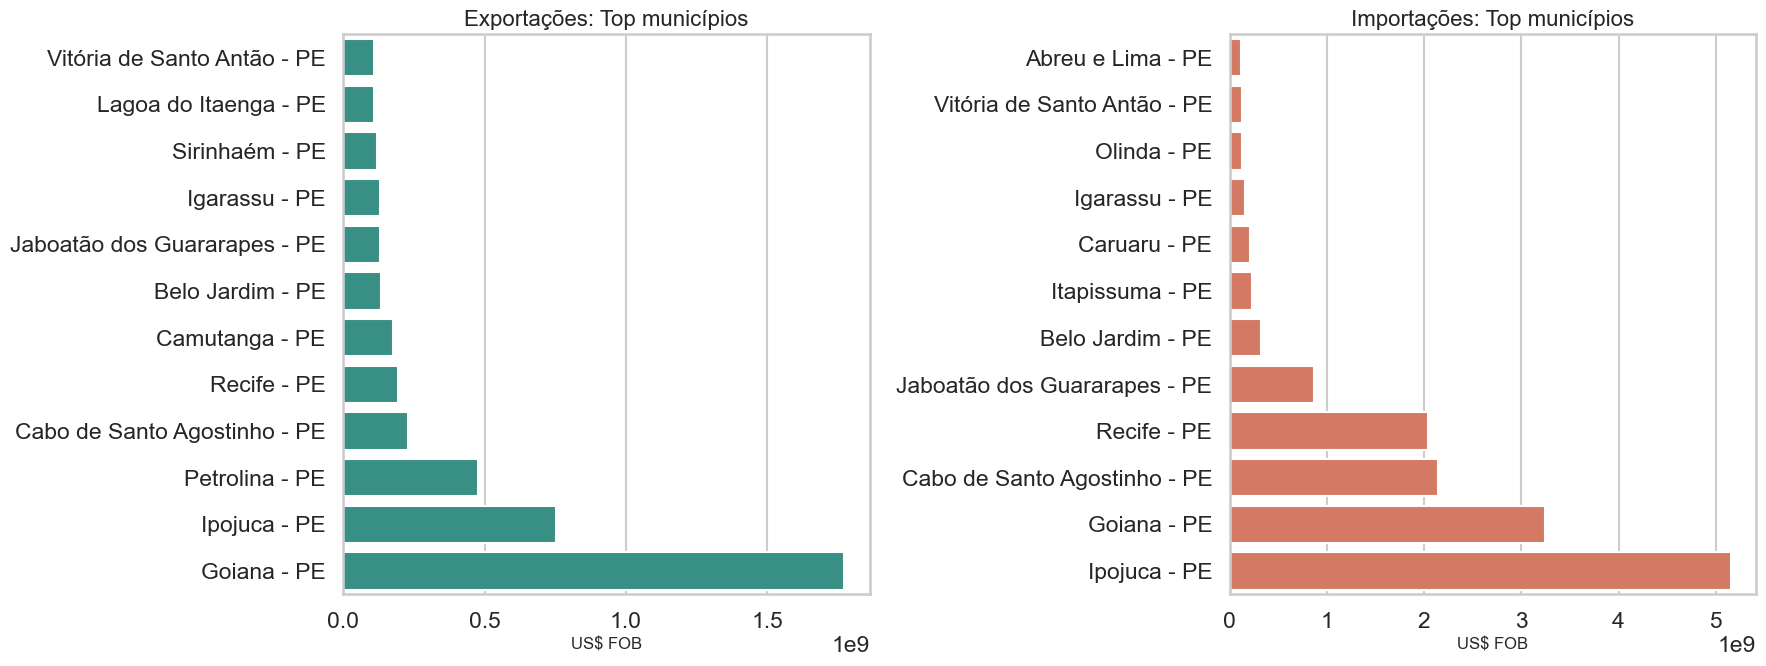

In [368]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False)

sns.barplot(data=exp_mun.sort_values("valor_usd"), y="Município", x="valor_usd", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Exportações: Top municípios")
axes[0].set_xlabel("US$ FOB")
axes[0].set_ylabel("")

sns.barplot(data=imp_mun.sort_values("valor_usd"), y="Município", x="valor_usd", ax=axes[1], color="#e76f51")
axes[1].set_title("Importações: Top municípios")
axes[1].set_xlabel("US$ FOB")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [369]:


# Concentração por município
for fluxo in ["Exportação", "Importação"]:
    base = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("Município", as_index=False)["Valor US$ FOB"].sum()
        .sort_values("Valor US$ FOB", ascending=False)
    )
    base["share"] = base["Valor US$ FOB"] / base["Valor US$ FOB"].sum()
    hhi = (base["share"] ** 2).sum()
    top5_share = base["share"].head(5).sum()
    print(f"{fluxo}: HHI municipal={hhi:.3f} | participacao Top-5={top5_share:.1%}")


Exportação: HHI municipal=0.194 | participacao Top-5=74.0%
Importação: HHI municipal=0.203 | participacao Top-5=88.5%


#### Análise de Concentração Municipal

**Índice Herfindahl-Hirschman (HHI):**
- HHI < 0,15: concentração baixa (mercado competitivo)
- 0,15 ≤ HHI < 0,25: concentração moderada
- HHI ≥ 0,25: concentração alta

**Participação Top-5:**
Indica o percentual do comércio concentrado nos 5 principais municípios.

### 4.3 Perfil Detalhado por Município

Análise aprofundada: **o que cada município exporta/importa e para onde/de onde**.

Esta análise revela:
- Especialização produtiva de cada município
- Principais produtos comercializados
- Principais parceiros comerciais
- Cadeias de valor município → produto → destino

In [370]:
def perfil_municipio(municipio: str, fluxo: str, top_n: int = 10) -> dict:
    """
    Cria perfil completo de comércio exterior de um município.
    
    Args:
        municipio: Nome do município (ex: 'Recife - PE')
        fluxo: 'Exportação' ou 'Importação'
        top_n: Número de itens no top ranking
        
    Returns:
        Dicionário com DataFrames de produtos, países e fluxos completos
    """
    data = df[(df["Município"] == municipio) & (df["Fluxo"] == fluxo)]
    
    # Resumo geral
    total_valor = data["Valor US$ FOB"].sum()
    total_peso = data["Quilograma Líquido"].sum()
    n_produtos = data["Código SH2"].nunique()
    n_paises = data["País"].nunique()
    
    # Top produtos
    top_produtos = (
        data.groupby(["Código SH2", "Descrição SH2"], as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum"),
            n_paises=("País", "nunique")
        )
        .sort_values("valor", ascending=False)
        .head(top_n)
    )
    top_produtos["share"] = (top_produtos["valor"] / total_valor * 100).round(1)
    top_produtos["usd_kg"] = np.where(
        top_produtos["peso"] > 0,
        top_produtos["valor"] / top_produtos["peso"],
        np.nan
    )
    
    # Top países
    top_paises = (
        data.groupby("País", as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum"),
            n_produtos=("Código SH2", "nunique")
        )
        .sort_values("valor", ascending=False)
        .head(top_n)
    )
    top_paises["share"] = (top_paises["valor"] / total_valor * 100).round(1)
    
    # Fluxos completos (produto → país)
    fluxos = (
        data.groupby(["Código SH2", "Descrição SH2", "País"], as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum")
        )
        .sort_values("valor", ascending=False)
        .head(20)
    )
    fluxos["share"] = (fluxos["valor"] / total_valor * 100).round(2)
    
    return {
        "municipio": municipio,
        "fluxo": fluxo,
        "resumo": {
            "total_valor": total_valor,
            "total_peso": total_peso,
            "n_produtos": n_produtos,
            "n_paises": n_paises,
            "valor_medio_kg": total_valor / total_peso if total_peso > 0 else 0
        },
        "top_produtos": top_produtos,
        "top_paises": top_paises,
        "fluxos_principais": fluxos
    }

print("Função de perfil municipal definida.")

Função de perfil municipal definida.


#### Exemplo: Perfil Completo de Recife - PE (Exportações)

In [371]:
# Analisa Recife
perfil_recife_exp = perfil_municipio("Recife - PE", "Exportação", top_n=10)

print("=" * 80)
print(f"PERFIL DE COMÉRCIO EXTERIOR: {perfil_recife_exp['municipio']}")
print(f"Fluxo: {perfil_recife_exp['fluxo']}")
print("=" * 80)

resumo = perfil_recife_exp['resumo']
print(f"\nRESUMO GERAL:")
print(f"  Valor total: {br_money(resumo['total_valor'])}")
print(f"  Peso total: {resumo['total_peso']:,.0f} kg")
print(f"  Valor médio: US$ {resumo['valor_medio_kg']:.2f}/kg")
print(f"  Produtos diferentes (SH2): {resumo['n_produtos']}")
print(f"  Países parceiros: {resumo['n_paises']}")

print(f"\nTOP PRODUTOS EXPORTADOS:")
print("=" * 80)
display(perfil_recife_exp['top_produtos'])

print(f"\nTOP DESTINOS:")
print("=" * 80)
display(perfil_recife_exp['top_paises'])

print(f"\nPRINCIPAIS FLUXOS (Produto → Destino):")
print("=" * 80)
display(perfil_recife_exp['fluxos_principais'])

,Código SH2,Descrição SH2,País,valor,peso,share
396,72,"Ferro fundido, ferro e aço",Peru,51915043,89801856,26.89
207,27,"Combustíveis minerais, óleos minerais e produt...",Portugal,31232444,36289063,16.18
15,03,"Peixes e crustáceos, moluscos e outros inverte...",Estados Unidos,15274180,1336757,7.91
196,27,"Combustíveis minerais, óleos minerais e produt...",Estados Unidos,11415010,13174302,5.91
463,85,"Máquinas, aparelhos e materiais elétricos, e s...",Japão,8121673,1211819,4.21
394,72,"Ferro fundido, ferro e aço",Guatemala,7773716,16412880,4.03
117,17,Açúcares e produtos de confeitaria,Estados Unidos,5739102,12286589,2.97
391,72,"Ferro fundido, ferro e aço",Colômbia,5285928,8792799,2.74
378,69,Produtos cerâmicos,Estados Unidos,4606174,3313003,2.39
13,03,"Peixes e crustáceos, moluscos e outros inverte...",China,3758063,197810,1.95


#### Comparação entre Múltiplos Municípios

In [372]:
# Compara os top 5 municípios exportadores
top_5_municipios = exp_mun.head(5)["Município"].tolist()

print("COMPARAÇÃO DE ESPECIALIZAÇÃO - TOP 5 MUNICÍPIOS EXPORTADORES")
print("=" * 80)

comparacao_especializacao = []

for mun in top_5_municipios:
    perfil = perfil_municipio(mun, "Exportação", top_n=3)
    
    # Pega os top 3 produtos
    top_3 = perfil['top_produtos'].head(3)
    produtos_str = " | ".join([
        f"{row['Código SH2']} ({row['share']:.0f}%)"
        for _, row in top_3.iterrows()
    ])
    
    # Pega os top 3 destinos
    top_3_dest = perfil['top_paises'].head(3)
    destinos_str = " | ".join([
        f"{row['País'][:15]} ({row['share']:.0f}%)"
        for _, row in top_3_dest.iterrows()
    ])
    
    comparacao_especializacao.append({
        "Município": mun,
        "Valor Total": br_money(perfil['resumo']['total_valor']),
        "Top 3 Produtos (SH2)": produtos_str,
        "Top 3 Destinos": destinos_str,
        "Diversificação": f"{perfil['resumo']['n_produtos']} produtos / {perfil['resumo']['n_paises']} países"
    })

df_comparacao = pd.DataFrame(comparacao_especializacao)
display(df_comparacao)

,Município,Valor Total,Top 3 Produtos (SH2),Top 3 Destinos,Diversificação
0,Goiana - PE,"US$ 1,77 bi",87 (100%) | 48 (0%) | 73 (0%),Argentina (69%) | México (17%) | Chile (4%),18 produtos / 44 países
1,Ipojuca - PE,"US$ 753,6 mi",27 (66%) | 39 (21%) | 17 (7%),Singapura (26%) | Estados Unidos (16%) | China...,26 produtos / 53 países
2,Petrolina - PE,"US$ 477,6 mi",08 (92%) | 20 (4%) | 11 (2%),Países Baixos ( (48%) | Reino Unido (15%) | Es...,20 produtos / 45 países
3,Cabo de Santo Agostinho - PE,"US$ 228,0 mi",83 (47%) | 39 (30%) | 73 (9%),Estados Unidos (28%) | Argentina (22%) | Chile...,62 produtos / 63 países
4,Recife - PE,"US$ 193,0 mi",72 (37%) | 27 (28%) | 03 (12%),Peru (27%) | Estados Unidos (20%) | Portugal (...,70 produtos / 105 países


---

## 4.4 Visualização Geográfica: Mapas de Pernambuco

Esta seção apresenta **visualizações espaciais** do comércio exterior pernambucano.

### Mapas incluídos:
1. **Mapa coroplético** - Valor por município (exportação/importação)
2. **Mapa de bolhas** - Tamanho proporcional ao volume
3. **Mapa de concentração** - Identificação visual de polos

### Bibliotecas para Mapas

Usaremos diferentes abordagens dependendo da disponibilidade:
- **folium**: mapas interativos
- **plotly**: visualizações interativas
- **matplotlib + dados geográficos**: mapas estáticos

### 4.4.1 Preparação dos Dados Geográficos

In [373]:
# Verifica bibliotecas disponíveis para mapas
import importlib

map_libs = {
    'folium': False,
    'plotly': False,
    'geopandas': False
}

for lib in map_libs.keys():
    try:
        importlib.import_module(lib)
        map_libs[lib] = True
    except ImportError:
        pass

print("BIBLIOTECAS DE MAPEAMENTO DISPONÍVEIS:")
print("=" * 60)
for lib, available in map_libs.items():
    status = "✓ Instalada" if available else "✗ Não instalada"
    print(f"{lib:15s}: {status}")

if not any(map_libs.values()):
    print("\n⚠ Nenhuma biblioteca de mapas instalada.")
    print("\nPara instalar:")
    print("  pip install folium")
    print("  pip install plotly")
    print("  pip install geopandas")
else:
    print("\n✓ Visualizações de mapa disponíveis!")

BIBLIOTECAS DE MAPEAMENTO DISPONÍVEIS:
folium         : ✗ Não instalada
plotly         : ✓ Instalada
geopandas      : ✗ Não instalada

✓ Visualizações de mapa disponíveis!


In [374]:
# Coordenadas aproximadas dos principais municípios de PE
# (para visualização quando não há shapefile disponível)

municipios_coords = {
    "Recife - PE": (-8.0476, -34.8770),
    "Jaboatão dos Guararapes - PE": (-8.1130, -35.0150),
    "Olinda - PE": (-8.0089, -34.8553),
    "Caruaru - PE": (-8.2820, -35.9760),
    "Petrolina - PE": (-9.3891, -40.5028),
    "Paulista - PE": (-7.9408, -34.8728),
    "Cabo de Santo Agostinho - PE": (-8.2836, -35.0349),
    "Camaragibe - PE": (-8.0208, -34.9786),
    "Garanhuns - PE": (-8.8900, -36.4927),
    "Vitória de Santo Antão - PE": (-8.1189, -35.2919),
    "Igarassu - PE": (-7.8342, -34.9064),
    "Abreu e Lima - PE": (-7.9017, -34.8989),
    "Ipojuca - PE": (-8.3981, -35.0636),
    "Serra Talhada - PE": (-7.9856, -38.2897),
    "Araripina - PE": (-7.5764, -40.4978),
    "Goiana - PE": (-7.5597, -35.0028),
    "Belo Jardim - PE": (-8.3358, -36.4239),
    "Arcoverde - PE": (-8.4189, -37.0536),
    "Ouricuri - PE": (-7.8819, -40.0811),
    "Escada - PE": (-8.3594, -35.2236),
    "Itapissuma - PE": (-7.7767, -34.8900)
}

print(f"Coordenadas cadastradas para {len(municipios_coords)} municípios")

Coordenadas cadastradas para 21 municípios


### 4.4.2 Mapa de Bolhas: Valor por Município

Visualização com **plotly** (se disponível) mostrando o valor de exportação/importação por município.
Tamanho das bolhas = valor comercializado.

In [375]:
# Prepara dados para mapa de bolhas
def preparar_dados_mapa(fluxo: str, top_n: int = 20):
    """
    Prepara dados agregados por município com coordenadas.
    """
    mun_data = (
        df[df["Fluxo"] == fluxo]
        .groupby("Município", as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum"),
            n_paises=("País", "nunique"),
            n_produtos=("Código SH2", "nunique")
        )
        .sort_values("valor", ascending=False)
        .head(top_n)
    )
    
    # Adiciona coordenadas
    mun_data["lat"] = mun_data["Município"].map(lambda x: municipios_coords.get(x, (None, None))[0])
    mun_data["lon"] = mun_data["Município"].map(lambda x: municipios_coords.get(x, (None, None))[1])
    
    # Remove municípios sem coordenadas
    mun_data = mun_data.dropna(subset=["lat", "lon"])
    
    # Calcula tamanho das bolhas (normalizado)
    mun_data["tamanho"] = (mun_data["valor"] / mun_data["valor"].max() * 100).round(0)
    
    return mun_data

map_data_exp = preparar_dados_mapa("Exportação", top_n=20)
map_data_imp = preparar_dados_mapa("Importação", top_n=20)

print(f"Municípios exportadores com coordenadas: {len(map_data_exp)}")
print(f"Municípios importadores com coordenadas: {len(map_data_imp)}")

Municípios exportadores com coordenadas: 11
Municípios importadores com coordenadas: 15


In [376]:
# Cria mapa de bolhas com plotly (se disponível)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Cria figura com subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Exportações por Município", "Importações por Município"),
        specs=[[{"type": "scattergeo"}, {"type": "scattergeo"}]]
    )
    
    # Mapa de exportações
    fig.add_trace(
        go.Scattergeo(
            lon=map_data_exp["lon"],
            lat=map_data_exp["lat"],
            text=map_data_exp["Município"].str.replace(" - PE", "") + "<br>" + 
                 map_data_exp["valor"].apply(br_money),
            mode="markers",
            marker=dict(
                size=map_data_exp["tamanho"],
                color=map_data_exp["valor"],
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(title="US$ FOB", x=0.45),
                line=dict(width=1, color="white")
            ),
            hovertemplate="<b>%{text}</b><br>Lat: %{lat}<br>Lon: %{lon}<extra></extra>"
        ),
        row=1, col=1
    )
    
    # Mapa de importações
    fig.add_trace(
        go.Scattergeo(
            lon=map_data_imp["lon"],
            lat=map_data_imp["lat"],
            text=map_data_imp["Município"].str.replace(" - PE", "") + "<br>" + 
                 map_data_imp["valor"].apply(br_money),
            mode="markers",
            marker=dict(
                size=map_data_imp["tamanho"],
                color=map_data_imp["valor"],
                colorscale="Reds",
                showscale=True,
                colorbar=dict(title="US$ FOB", x=1.05),
                line=dict(width=1, color="white")
            ),
            hovertemplate="<b>%{text}</b><br>Lat: %{lat}<br>Lon: %{lon}<extra></extra>"
        ),
        row=1, col=2
    )
    
    # Configuração do mapa (foco em Pernambuco)
    fig.update_geos(
        center=dict(lat=-8.3, lon=-36.5),
        projection_scale=15,
        showcountries=True,
        showsubunits=True,
        showland=True,
        landcolor="rgb(243, 243, 243)",
        coastlinecolor="rgb(204, 204, 204)",
        projection_type="mercator"
    )
    
    fig.update_layout(
        title_text="Mapa de Comércio Exterior - Pernambuco (Tamanho = Valor)",
        height=600,
        showlegend=False
    )
    
    fig.show()
    print("\n✓ Mapa interativo gerado com sucesso!")
    print("  → Passe o mouse sobre as bolhas para detalhes")
    print("  → Tamanho da bolha = valor comercializado")
    
except ImportError:
    print("⚠ Plotly não está instalado. Pulando mapa interativo.")
    print("\nPara instalar: pip install plotly")
except Exception as e:
    print(f"⚠ Erro ao criar mapa: {e}")
    print("  → Verifique se os dados estão corretos")
plt.show()


✓ Mapa interativo gerado com sucesso!
  → Passe o mouse sobre as bolhas para detalhes
  → Tamanho da bolha = valor comercializado


### 4.4.3 Mapa Alternativo: Matplotlib

Visualização simples usando matplotlib (sempre disponível).

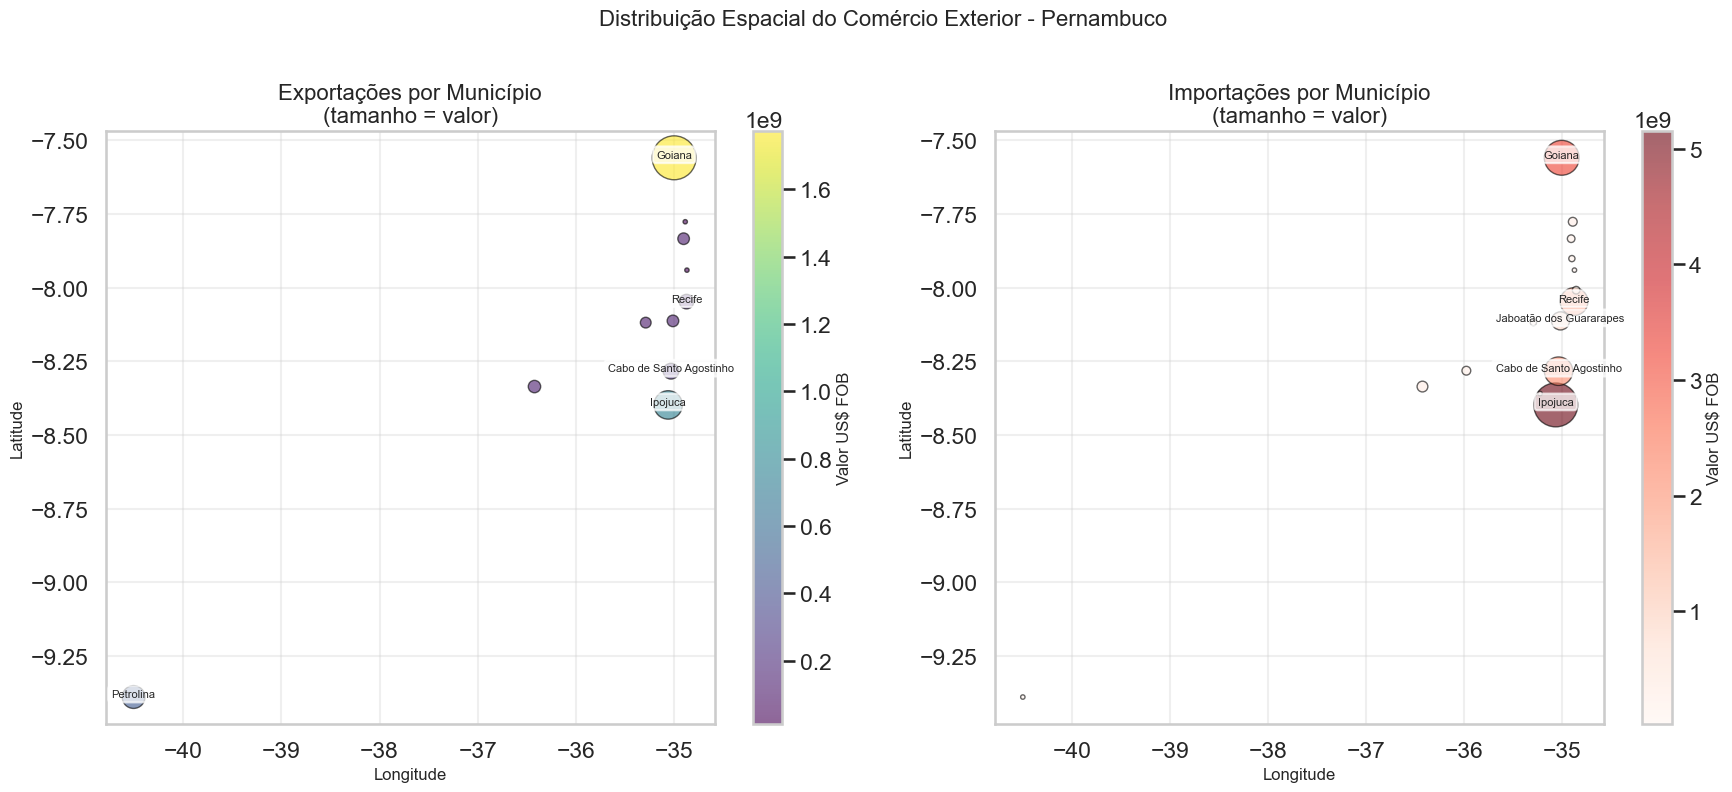

In [377]:
# Mapa simples com matplotlib (sempre funciona)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Mapa de exportações
ax1 = axes[0]
scatter1 = ax1.scatter(
    map_data_exp["lon"],
    map_data_exp["lat"],
    s=map_data_exp["tamanho"] * 10,
    c=map_data_exp["valor"],
    cmap="viridis",
    alpha=0.6,
    edgecolors="black",
    linewidth=1
)

# Anota os top 5
for idx, row in map_data_exp.head(5).iterrows():
    ax1.annotate(
        row["Município"].replace(" - PE", ""),
        (row["lon"], row["lat"]),
        fontsize=8,
        ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("Exportações por Município\n(tamanho = valor)")
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label="Valor US$ FOB")

# Mapa de importações
ax2 = axes[1]
scatter2 = ax2.scatter(
    map_data_imp["lon"],
    map_data_imp["lat"],
    s=map_data_imp["tamanho"] * 10,
    c=map_data_imp["valor"],
    cmap="Reds",
    alpha=0.6,
    edgecolors="black",
    linewidth=1
)

# Anota os top 5
for idx, row in map_data_imp.head(5).iterrows():
    ax2.annotate(
        row["Município"].replace(" - PE", ""),
        (row["lon"], row["lat"]),
        fontsize=8,
        ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("Importações por Município\n(tamanho = valor)")
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label="Valor US$ FOB")

plt.suptitle("Distribuição Espacial do Comércio Exterior - Pernambuco", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [378]:
print("\n✓ Mapa estático gerado")
print("  → Bolhas maiores = maior valor comercializado")
print("  → Top 5 municípios estão anotados")


✓ Mapa estático gerado
  → Bolhas maiores = maior valor comercializado
  → Top 5 municípios estão anotados


### 4.4.4 Análise Espacial: Concentração Geográfica

Identifica regiões/clusters de concentração comercial.

In [379]:
# Análise de concentração geográfica
print("ANÁLISE DE CONCENTRAÇÃO GEOGRÁFICA")
print("=" * 80)

# Região Metropolitana do Recife (RMR)
rmr_municipios = [
    "Recife - PE", "Jaboatão dos Guararapes - PE", "Olinda - PE",
    "Paulista - PE", "Cabo de Santo Agostinho - PE", "Camaragibe - PE",
    "Igarassu - PE", "Abreu e Lima - PE", "Ipojuca - PE", "Itapissuma - PE"
]

for fluxo in ["Exportação", "Importação"]:
    total_pe = df[df["Fluxo"] == fluxo]["Valor US$ FOB"].sum()
    total_rmr = df[
        (df["Fluxo"] == fluxo) & 
        (df["Município"].isin(rmr_municipios))
    ]["Valor US$ FOB"].sum()
    
    share_rmr = (total_rmr / total_pe * 100) if total_pe > 0 else 0
    
    print(f"\n{fluxo}:")
    print(f"  Total PE: {br_money(total_pe)}")
    print(f"  Total RMR: {br_money(total_rmr)}")
    print(f"  Concentração RMR: {share_rmr:.1f}% do estado")

# Litoral vs Interior
municipios_litoral = [
    "Recife - PE", "Jaboatão dos Guararapes - PE", "Olinda - PE",
    "Cabo de Santo Agostinho - PE", "Ipojuca - PE", "Goiana - PE",
    "Igarassu - PE", "Itapissuma - PE", "Paulista - PE"
]

print("\n" + "-" * 80)
print("LITORAL VS INTERIOR:")

for fluxo in ["Exportação", "Importação"]:
    total = df[df["Fluxo"] == fluxo]["Valor US$ FOB"].sum()
    litoral = df[
        (df["Fluxo"] == fluxo) & 
        (df["Município"].isin(municipios_litoral))
    ]["Valor US$ FOB"].sum()
    interior = total - litoral
    
    print(f"\n{fluxo}:")
    print(f"  Litoral: {br_money(litoral)} ({litoral/total*100:.1f}%)")
    print(f"  Interior: {br_money(interior)} ({interior/total*100:.1f}%)")


Importação:
  Litoral: US$ 14,03 bi (92.3%)
  Interior: US$ 1,17 bi (7.7%)


---

## 5. Parceiros Internacionais e Blocos Econômicos

Análise em duas dimensões:

### 5.1 Países Parceiros
Identifica os principais destinos e origens do comércio bilateral.

In [380]:

def top_parceiros(fluxo: str, top_n: int = 15) -> pd.DataFrame:
    out = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("País", as_index=False)
        .agg(valor_usd=("Valor US$ FOB", "sum"), kg=("Quilograma Líquido", "sum"))
        .sort_values("valor_usd", ascending=False)
        .head(top_n)
    )
    out["usd_kg"] = np.where(out["kg"] > 0, out["valor_usd"] / out["kg"], np.nan)
    out["share"] = out["valor_usd"] / out["valor_usd"].sum()
    return out

exp_country = top_parceiros("Exportação", top_n=12)
imp_country = top_parceiros("Importação", top_n=12)

print("Top destinos das exportacoes")
display(exp_country)
print("Top origens das importacoes")
display(imp_country)

block_mix = (
    df_block.groupby(["Fluxo", "Bloco Econômico"], as_index=False)["Valor US$ FOB"].sum()
    .sort_values(["Fluxo", "Valor US$ FOB"], ascending=[True, False])
)
block_mix["share_fluxo"] = block_mix["Valor US$ FOB"] / block_mix.groupby("Fluxo")["Valor US$ FOB"].transform("sum")

print("Mix por bloco economico (um bloco por transacao)")
display(block_mix.head(20))


,Fluxo,Bloco Econômico,Valor US$ FOB,share_fluxo
6,Exportação,Mercado Comum do Sul - Mercosul,1728207021,0.373342
1,Exportação,América do Norte,774926742,0.167406
10,Exportação,África,558883709,0.120735
9,Exportação,União Europeia - UE,487108700,0.10523
2,Exportação,América do Sul,215709863,0.0466
3,Exportação,Associação de Nações do Sudeste Asiático - ASEAN,214524100,0.046343
11,Exportação,Ásia (Exclusive Oriente Médio),212118245,0.045824
4,Exportação,Comunidade Andina das Nações - CAN,182823616,0.039495
5,Exportação,Europa,110003335,0.023764
0,Exportação,América Central e Caribe,86895114,0.018772


#### Interpretação: Países Parceiros

**Perguntas-chave:**
- Há dependência excessiva de poucos mercados?
- Os parceiros principais são mercados estáveis?
- Existem oportunidades de expansão para novos mercados?
- O valor unitário (US$/kg) varia significativamente por país?

### 5.2 Perfil Detalhado de Parceiros Comerciais

Análise aprofundada: **o que cada país compra de PE e o que vende para PE**.

Esta seção responde:
- Quais produtos cada país importa de Pernambuco?
- Quais produtos cada país exporta para Pernambuco?
- Quais municípios pernambucanos comercializam com cada país?
- Volume x Valor: países compradores de alto valor agregado

In [381]:
def perfil_parceiro(pais: str, fluxo: str, top_n: int = 10) -> dict:
    """
    Cria perfil completo de comércio com um país parceiro.
    
    Args:
        pais: Nome do país
        fluxo: 'Exportação' (PE → país) ou 'Importação' (país → PE)
        top_n: Número de itens no ranking
        
    Returns:
        Dicionário com análises do perfil comercial
    """
    data = df[(df["País"] == pais) & (df["Fluxo"] == fluxo)]
    
    total_valor = data["Valor US$ FOB"].sum()
    total_peso = data["Quilograma Líquido"].sum()
    
    # Top produtos comercializados
    top_produtos = (
        data.groupby(["Código SH2", "Descrição SH2"], as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum"),
            n_municipios=("Município", "nunique")
        )
        .sort_values("valor", ascending=False)
        .head(top_n)
    )
    top_produtos["share"] = (top_produtos["valor"] / total_valor * 100).round(1)
    top_produtos["usd_kg"] = np.where(
        top_produtos["peso"] > 0,
        top_produtos["valor"] / top_produtos["peso"],
        np.nan
    )
    
    # Top municípios que comercializam
    top_municipios = (
        data.groupby("Município", as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum"),
            n_produtos=("Código SH2", "nunique")
        )
        .sort_values("valor", ascending=False)
        .head(top_n)
    )
    top_municipios["share"] = (top_municipios["valor"] / total_valor * 100).round(1)
    
    # Fluxos município → produto
    fluxos = (
        data.groupby(["Município", "Código SH2", "Descrição SH2"], as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum")
        )
        .sort_values("valor", ascending=False)
        .head(15)
    )
    fluxos["share"] = (fluxos["valor"] / total_valor * 100).round(2)
    
    return {
        "pais": pais,
        "fluxo": fluxo,
        "resumo": {
            "total_valor": total_valor,
            "total_peso": total_peso,
            "n_produtos": data["Código SH2"].nunique(),
            "n_municipios": data["Município"].nunique(),
            "valor_medio_kg": total_valor / total_peso if total_peso > 0 else 0
        },
        "top_produtos": top_produtos,
        "top_municipios": top_municipios,
        "fluxos_principais": fluxos
    }

print("Função de perfil de parceiro definida.")

Função de perfil de parceiro definida.


#### Exemplo: O que a China compra de Pernambuco?

In [382]:
# Analisa exportações para a China
perfil_china_exp = perfil_parceiro("China", "Exportação", top_n=8)

print("=" * 80)
print(f"O QUE A {perfil_china_exp['pais'].upper()} COMPRA DE PERNAMBUCO")
print("=" * 80)

resumo = perfil_china_exp['resumo']
print(f"\nRESUMO:")
print(f"  Valor total exportado: {br_money(resumo['total_valor'])}")
print(f"  Peso total: {resumo['total_peso']:,.0f} kg")
print(f"  Valor médio: US$ {resumo['valor_medio_kg']:.2f}/kg")
print(f"  Produtos diferentes: {resumo['n_produtos']}")
print(f"  Municípios exportadores: {resumo['n_municipios']}")

print(f"\nPRINCIPAIS PRODUTOS EXPORTADOS PARA A CHINA:")
print("=" * 80)
display(perfil_china_exp['top_produtos'][["Código SH2", "Descrição SH2", "valor", "share", "usd_kg", "n_municipios"]])

print(f"\nMUNICÍPIOS QUE EXPORTAM PARA A CHINA:")
print("=" * 80)
display(perfil_china_exp['top_municipios'])

print(f"\nPRINCIPAIS FLUXOS (Município → Produto):")
print("=" * 80)
display(perfil_china_exp['fluxos_principais'][["Município", "Código SH2", "Descrição SH2", "valor", "share"]])

,Município,Código SH2,Descrição SH2,valor,share
20,Ipojuca - PE,27,"Combustíveis minerais, óleos minerais e produt...",107416884,84.71
9,Cabo de Santo Agostinho - PE,40,Borracha e suas obras,6286793,4.96
41,Recife - PE,03,"Peixes e crustáceos, moluscos e outros inverte...",3758063,2.96
6,Bom Jardim - PE,25,"Sal; enxofre; terras e pedras; gesso, cal e ci...",2490416,1.96
24,Ipojuca - PE,73,"Obras de ferro fundido, ferro ou aço",2000824,1.58
39,Petrolina - PE,20,"Preparações de produtos hortícolas, de frutas ...",1651245,1.3
27,Ipojuca - PE,84,"Reatores nucleares, caldeiras, máquinas, apare...",907710,0.72
12,Cabo de Santo Agostinho - PE,76,Alumínio e suas obras,569581,0.45
22,Ipojuca - PE,68,"Obras de pedra, gesso, cimento, amianto, mica ...",352440,0.28
8,Cabo de Santo Agostinho - PE,39,Plásticos e suas obras,321204,0.25


#### Análise Comparativa: Perfil de Compras dos Top 5 Parceiros

In [383]:
# Compara o que os top 5 destinos de exportação compram de PE
top_5_destinos = exp_country.head(5)["País"].tolist()

print("PERFIL DE COMPRAS - TOP 5 DESTINOS DE EXPORTAÇÃO")
print("=" * 80)
print("\nO que cada país compra de Pernambuco?\n")

comparacao_parceiros = []

for pais in top_5_destinos:
    perfil = perfil_parceiro(pais, "Exportação", top_n=3)
    
    # Top 3 produtos
    top_3_prod = perfil['top_produtos'].head(3)
    produtos_str = " | ".join([
        f"{row['Código SH2']} ({row['share']:.0f}%)"
        for _, row in top_3_prod.iterrows()
    ])
    
    # Top 2 municípios fornecedores
    top_2_mun = perfil['top_municipios'].head(2)
    municipios_str = " | ".join([
        f"{row['Município'].replace(' - PE', '')} ({row['share']:.0f}%)"
        for _, row in top_2_mun.iterrows()
    ])
    
    comparacao_parceiros.append({
        "País": pais,
        "Valor": br_money(perfil['resumo']['total_valor']),
        "US$/kg": f"{perfil['resumo']['valor_medio_kg']:.2f}",
        "Top 3 Produtos Comprados": produtos_str,
        "Principais Fornecedores (PE)": municipios_str
    })

df_comp_parceiros = pd.DataFrame(comparacao_parceiros)
display(df_comp_parceiros)

,País,Valor,US$/kg,Top 3 Produtos Comprados,Principais Fornecedores (PE)
0,Argentina,"US$ 1,55 bi",6.34,87 (79%) | 85 (8%) | 39 (6%),Goiana (79%) | Ipojuca (6%)
1,Estados Unidos,"US$ 396,0 mi",0.96,27 (30%) | 17 (21%) | 08 (14%),Ipojuca (30%) | Petrolina (17%)
2,México,"US$ 322,6 mi",5.19,87 (95%) | 17 (2%) | 72 (1%),Goiana (95%) | Lagoa do Itaenga (2%)
3,Países Baixos (Holanda),"US$ 311,5 mi",1.41,08 (94%) | 20 (3%) | 09 (1%),Petrolina (74%) | Belém de São Francisco (19%)
4,Singapura,"US$ 205,0 mi",0.54,27 (95%) | 02 (5%) | 72 (0%),Ipojuca (95%) | Canhotinho (5%)


#### Análise: De onde vêm as Importações de Pernambuco?

Agora invertemos a análise: **o que PE compra de cada país**.

In [384]:
# Analisa o que PE importa da China
perfil_china_imp = perfil_parceiro("China", "Importação", top_n=10)

print("=" * 80)
print(f"O QUE PERNAMBUCO COMPRA DA {perfil_china_imp['pais'].upper()}")
print("=" * 80)

resumo = perfil_china_imp['resumo']
print(f"\nRESUMO:")
print(f"  Valor total importado: {br_money(resumo['total_valor'])}")
print(f"  Peso total: {resumo['total_peso']:,.0f} kg")
print(f"  Valor médio: US$ {resumo['valor_medio_kg']:.2f}/kg")
print(f"  Produtos diferentes: {resumo['n_produtos']}")
print(f"  Municípios importadores: {resumo['n_municipios']}")

print(f"\nPRINCIPAIS PRODUTOS IMPORTADOS DA CHINA:")
print("=" * 80)
display(perfil_china_imp['top_produtos'][["Código SH2", "Descrição SH2", "valor", "share", "usd_kg"]])

print(f"\nMUNICÍPIOS QUE IMPORTAM DA CHINA:")
print("=" * 80)
display(perfil_china_imp['top_municipios'])

,Município,valor,peso,n_produtos,share
11,Cabo de Santo Agostinho - PE,921767091,228105000,52,31.4
45,Recife - PE,622474171,413426093,80,21.2
29,Jaboatão dos Guararapes - PE,429099708,240976748,58,14.6
22,Goiana - PE,189321569,16368658,17,6.4
26,Ipojuca - PE,188165111,142133473,41,6.4
15,Caruaru - PE,154612502,70746632,62,5.3
0,Abreu e Lima - PE,61832048,80864498,36,2.1
50,Santa Cruz do Capibaribe - PE,56812997,28040142,43,1.9
6,Belo Jardim - PE,56748707,8360784,21,1.9
36,Olinda - PE,54709506,20496793,28,1.9


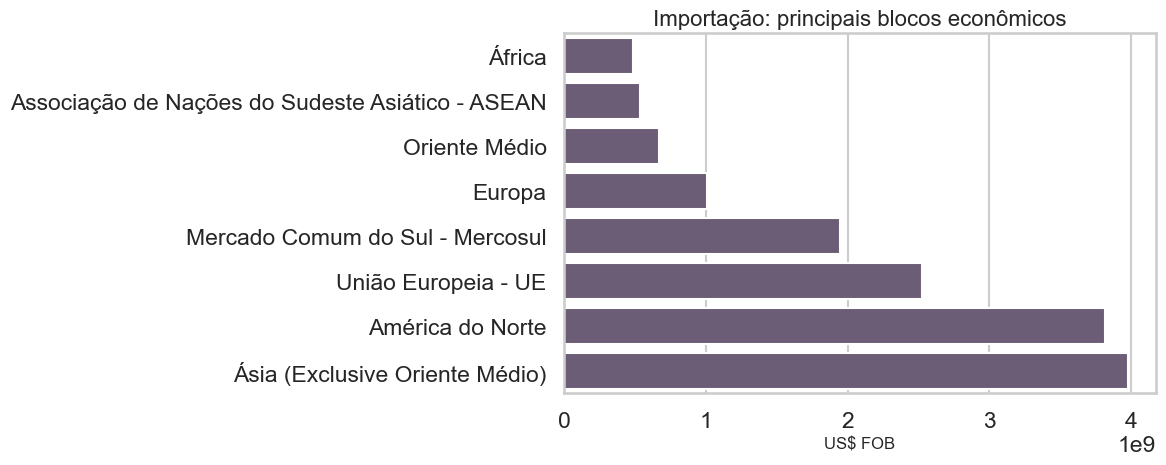

In [385]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=exp_country.sort_values("valor_usd"), y="País", x="valor_usd", ax=axes[0], color="#457b9d")
axes[0].set_title("Exportações: principais destinos")
axes[0].set_xlabel("US$ FOB")
axes[0].set_ylabel("")

sns.barplot(data=imp_country.sort_values("valor_usd"), y="País", x="valor_usd", ax=axes[1], color="#f4a261")
axes[1].set_title("Importações: principais origens")
axes[1].set_xlabel("US$ FOB")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

for fluxo in ["Exportação", "Importação"]:
    temp = block_mix[block_mix["Fluxo"].eq(fluxo)].head(8)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=temp.sort_values("Valor US$ FOB"), y="Bloco Econômico", x="Valor US$ FOB", ax=ax, color="#6d597a")
    ax.set_title(f"{fluxo}: principais blocos econômicos")
    ax.set_xlabel("US$ FOB")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


---

## 6. Estrutura da Pauta: Produtos e Setores

### 6.1 Análise por Código SH2 (Sistema Harmonizado - 2 dígitos)

O Sistema Harmonizado é a classificação internacional padrão para produtos comercializados.
O nível SH2 agrupa produtos em 99 capítulos principais.

In [386]:

def top_produtos_sh2(fluxo: str, top_n: int = 15) -> pd.DataFrame:
    out = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby(["Código SH2", "Descrição SH2"], as_index=False)
        .agg(valor_usd=("Valor US$ FOB", "sum"), kg=("Quilograma Líquido", "sum"))
        .sort_values("valor_usd", ascending=False)
        .head(top_n)
    )
    out["usd_kg"] = np.where(out["kg"] > 0, out["valor_usd"] / out["kg"], np.nan)
    out["share"] = out["valor_usd"] / out["valor_usd"].sum()
    return out

exp_sh2 = top_produtos_sh2("Exportação")
imp_sh2 = top_produtos_sh2("Importação")

print("Top SH2 - Exportacao")
display(exp_sh2)
print("Top SH2 - Importacao")
display(imp_sh2)

section_mix = (
    df.groupby(["Fluxo", "Código Seção", "Descrição Seção"], as_index=False)["Valor US$ FOB"].sum()
    .sort_values(["Fluxo", "Valor US$ FOB"], ascending=[True, False])
)
section_mix["share_fluxo"] = section_mix["Valor US$ FOB"] / section_mix.groupby("Fluxo")["Valor US$ FOB"].transform("sum")

print("Mix por secao NCM")
display(section_mix.head(20))


,Fluxo,Código Seção,Descrição Seção,Valor US$ FOB,share_fluxo
17,Exportação,XVII,Material de transporte,1786862648,0.386014
3,Exportação,IV,"Produtos das indútrias alimentares; Bebidas, l...",809639389,0.174905
1,Exportação,II,Produtos do reino vegetal,587520309,0.126921
5,Exportação,V,Produtos minerais,554793556,0.119851
7,Exportação,VII,Plásticos e suas obras; Borracha e suas obras,252806699,0.054614
15,Exportação,XV,Metais comuns e suas obras,237264969,0.051256
16,Exportação,XVI,"Máquinas e aparelhos, material elétrico e suas...",225971945,0.048816
0,Exportação,I,Animais vivos e produtos do reino animal,83016788,0.017934
6,Exportação,VI,Produtos das indústrias químicas ou indústrias...,34835927,0.007526
12,Exportação,XIII,"Obras de pedra, gesso, cimento, amianto, mica ...",15354698,0.003317


### 6.2 Visualização e Concentração da Pauta

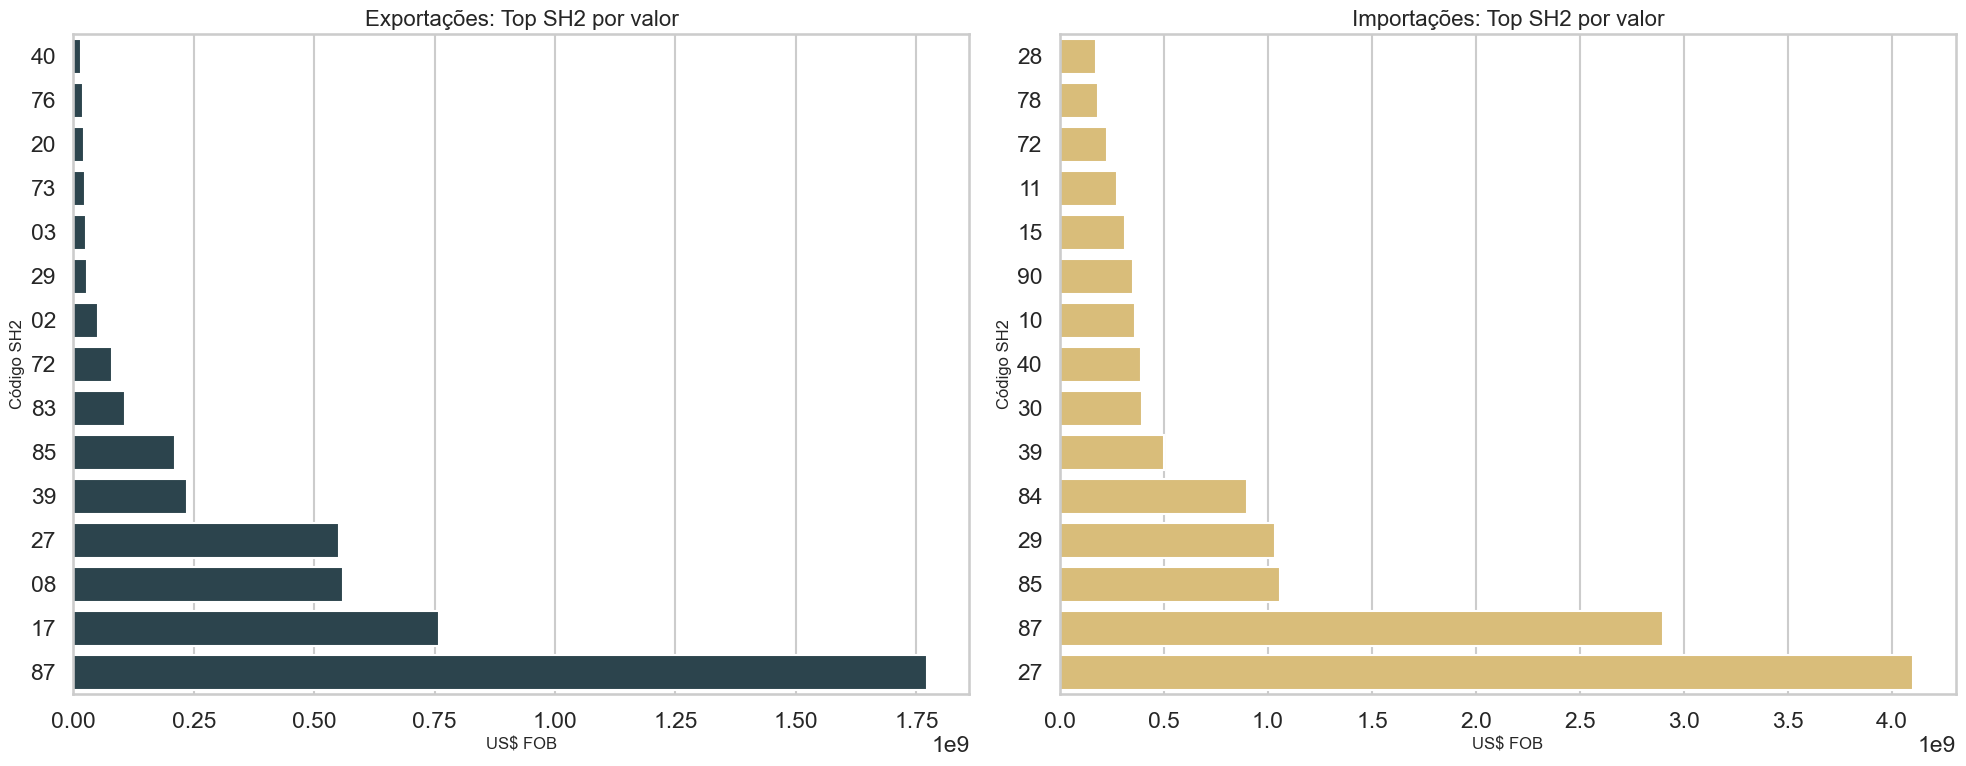

In [387]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=exp_sh2.sort_values("valor_usd"), y="Código SH2", x="valor_usd", ax=axes[0], color="#264653")
axes[0].set_title("Exportações: Top SH2 por valor")
axes[0].set_xlabel("US$ FOB")
axes[0].set_ylabel("Código SH2")

sns.barplot(data=imp_sh2.sort_values("valor_usd"), y="Código SH2", x="valor_usd", ax=axes[1], color="#e9c46a")
axes[1].set_title("Importações: Top SH2 por valor")
axes[1].set_xlabel("US$ FOB")
axes[1].set_ylabel("Código SH2")

plt.tight_layout()
plt.show()

In [388]:


# Concentração da pauta (HHI por SH2)
for fluxo in ["Exportação", "Importação"]:
    temp = (
        df[df["Fluxo"].eq(fluxo)]
        .groupby("Código SH2", as_index=False)["Valor US$ FOB"].sum()
        .sort_values("Valor US$ FOB", ascending=False)
    )
    temp["share"] = temp["Valor US$ FOB"] / temp["Valor US$ FOB"].sum()
    hhi = (temp["share"] ** 2).sum()
    top3 = temp["share"].head(3).sum()
    print(f"{fluxo}: HHI da pauta SH2={hhi:.3f} | participacao Top-3 SH2={top3:.1%}")


Exportação: HHI da pauta SH2=0.208 | participacao Top-3 SH2=66.8%
Importação: HHI da pauta SH2=0.128 | participacao Top-3 SH2=53.0%


#### Interpretação: Diversificação da Pauta

**HHI da Pauta:**
- Quanto maior o HHI, mais concentrada é a pauta em poucos produtos
- Alta concentração aumenta vulnerabilidade a choques específicos de mercado

**Valor Agregado:**
- Compare o US$/kg entre produtos
- Produtos com maior valor unitário tendem a ter maior sofisticação tecnológica

---

## 6.3 Análise de Cadeias e Fluxos Completos

Esta seção mapeia as **cadeias completas de comércio exterior**:

**Município → Produto → País → Valor/Volume**

Permite responder:
- Quais são os fluxos comerciais mais relevantes?
- Como os produtos transitam da origem ao destino?
- Quais cadeias têm maior valor agregado?
- Onde estão as oportunidades de fortalecimento de cadeias?

In [389]:
def analise_cadeias_completas(fluxo: str, top_n: int = 30) -> pd.DataFrame:
    """
    Mapeia as principais cadeias completas de comércio exterior.
    
    Args:
        fluxo: 'Exportação' ou 'Importação'
        top_n: Número de cadeias principais
        
    Returns:
        DataFrame com cadeias ordenadas por valor
    """
    cadeias = (
        df[df["Fluxo"] == fluxo]
        .groupby(["Município", "Código SH2", "Descrição SH2", "País"], as_index=False)
        .agg(
            valor=("Valor US$ FOB", "sum"),
            peso=("Quilograma Líquido", "sum"),
            n_transacoes=("Valor US$ FOB", "count")
        )
        .sort_values("valor", ascending=False)
        .head(top_n)
    )
    
    total = df[df["Fluxo"] == fluxo]["Valor US$ FOB"].sum()
    cadeias["share_total"] = (cadeias["valor"] / total * 100).round(2)
    cadeias["usd_kg"] = np.where(
        cadeias["peso"] > 0,
        cadeias["valor"] / cadeias["peso"],
        np.nan
    )
    
    # Cria identificador de cadeia
    cadeias["Cadeia"] = (
        cadeias["Município"].str.replace(" - PE", "") + 
        " → " + cadeias["Código SH2"] + 
        " → " + cadeias["País"]
    )
    
    return cadeias

print("Função de análise de cadeias definida.")

Função de análise de cadeias definida.


#### Top 20 Cadeias de Exportação

In [390]:
# Principais cadeias de exportação
cadeias_exp = analise_cadeias_completas("Exportação", top_n=20)

print("TOP 20 CADEIAS DE EXPORTAÇÃO DE PERNAMBUCO")
print("=" * 80)
print("\nFormato: Município → Produto (SH2) → País Destino\n")

display(cadeias_exp[[
    "Cadeia", "Descrição SH2", "valor", "peso", 
    "share_total", "usd_kg", "n_transacoes"
]])

# Métricas agregadas
print(f"\nANÁLISE DAS TOP 20 CADEIAS:")
print("=" * 80)
print(f"Concentração: {cadeias_exp['share_total'].sum():.1f}% do valor total de exportações")
print(f"Valor médio por cadeia: {br_money(cadeias_exp['valor'].mean())}")
print(f"Valor médio geral: US$ {cadeias_exp['usd_kg'].mean():.2f}/kg")
print(f"\nCadeia de maior valor: {cadeias_exp.iloc[0]['Cadeia']}")
print(f"  Valor: {br_money(cadeias_exp.iloc[0]['valor'])}")
print(f"  US$/kg: {cadeias_exp.iloc[0]['usd_kg']:.2f}")


ANÁLISE DAS TOP 20 CADEIAS:
Concentração: 63.8% do valor total de exportações
Valor médio por cadeia: US$ 147,6 mi
Valor médio geral: US$ 5.48/kg

Cadeia de maior valor: Goiana → 87 → Argentina
  Valor: US$ 1,22 bi
  US$/kg: 12.51


#### Top 20 Cadeias de Importação

In [391]:
# Principais cadeias de importação
cadeias_imp = analise_cadeias_completas("Importação", top_n=20)

print("TOP 20 CADEIAS DE IMPORTAÇÃO DE PERNAMBUCO")
print("=" * 80)
print("\nFormato: Município Importador ← Produto (SH2) ← País Origem\n")

display(cadeias_imp[[
    "Cadeia", "Descrição SH2", "valor", "peso",
    "share_total", "usd_kg", "n_transacoes"
]])

print(f"\nANÁLISE DAS TOP 20 CADEIAS DE IMPORTAÇÃO:")
print("=" * 80)
print(f"Concentração: {cadeias_imp['share_total'].sum():.1f}% do valor total de importações")
print(f"Valor médio por cadeia: {br_money(cadeias_imp['valor'].mean())}")


ANÁLISE DAS TOP 20 CADEIAS DE IMPORTAÇÃO:
Concentração: 47.4% do valor total de importações
Valor médio por cadeia: US$ 360,5 mi


#### Matriz de Fluxos: Produto x País

Visualização em matriz mostrando quais produtos vão para quais países (exportação).

In [392]:
# Cria matriz produto x país para exportações
# Top 10 produtos x Top 10 países

top_10_produtos_exp = (
    df[df["Fluxo"] == "Exportação"]
    .groupby("Código SH2")["Valor US$ FOB"]
    .sum()
    .nlargest(10)
    .index.tolist()
)

top_10_paises_exp = exp_country.head(10)["País"].tolist()

matriz_exp = (
    df[
        (df["Fluxo"] == "Exportação") &
        (df["Código SH2"].isin(top_10_produtos_exp)) &
        (df["País"].isin(top_10_paises_exp))
    ]
    .groupby(["Código SH2", "País"])["Valor US$ FOB"]
    .sum()
    .unstack(fill_value=0)
)

# Converte para milhões para melhor visualização
matriz_exp_mi = (matriz_exp / 1e6).round(1)

print("MATRIZ DE FLUXOS DE EXPORTAÇÃO")
print("Valores em US$ milhões | Produtos (SH2) x Países")
print("=" * 80)
display(matriz_exp_mi)

País,Argentina,Chile,China,"Congo, República Democrática",Estados Unidos,México,Países Baixos (Holanda),Peru,Reino Unido,Singapura
Código SH2,,,,,,,,,,
02,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.5,0.0,10.0
08,19.9,1.3,0.0,0.0,56.4,0.0,294.3,0.0,87.5,0.0
17,0.0,0.0,0.0,128.9,84.4,6.9,0.2,0.0,0.2,0.0
27,0.3,1.8,107.4,0.0,120.9,2.7,0.2,0.0,1.3,194.4
29,28.6,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0
39,92.3,1.5,0.3,0.0,40.1,0.7,0.0,1.6,0.2,0.0
72,0.1,0.0,0.0,0.0,0.0,3.0,0.2,51.9,0.0,0.3
83,27.5,44.7,0.0,0.0,0.0,0.0,0.0,17.8,0.0,0.0
85,125.7,1.1,0.0,0.0,1.1,2.2,0.1,2.8,0.0,0.0


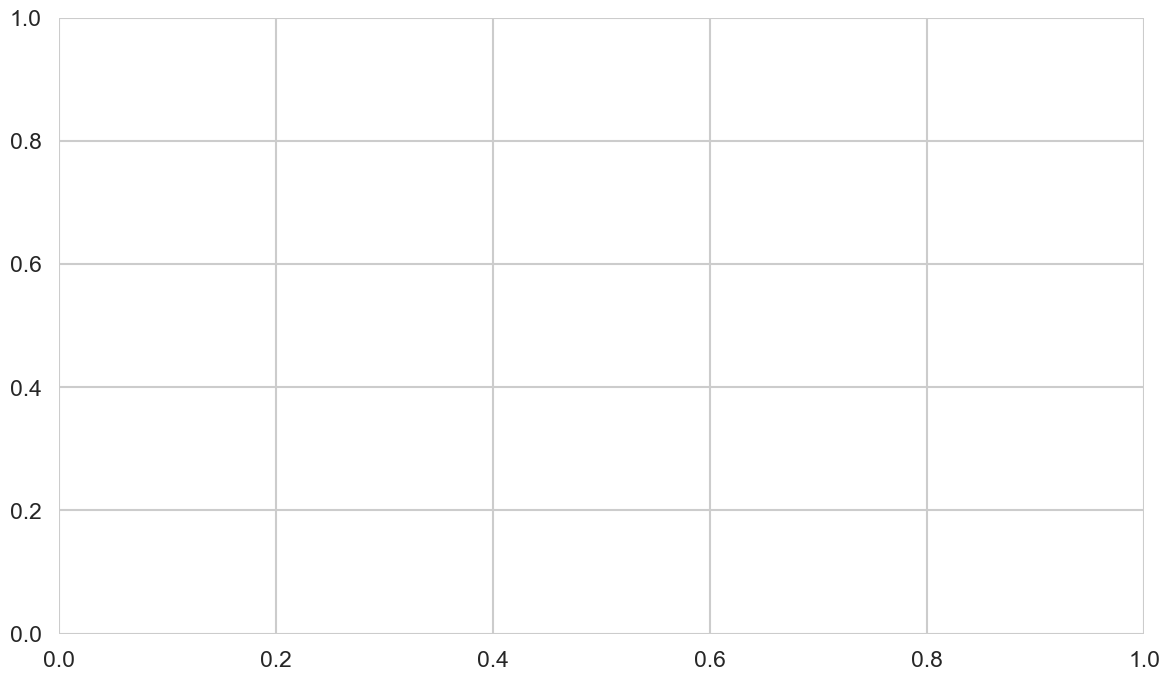

In [393]:
# Heatmap da matriz
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    matriz_exp_mi,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={"label": "US$ milhões"},
    ax=ax
)
ax.set_title("Matriz de Exportações: Produtos x Países (US$ milhões)", fontsize=14, pad=20)
ax.set_xlabel("País Destino", fontsize=12)
ax.set_ylabel("Produto (SH2)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:


# Insights
print("\nINSIGHTS DA MATRIZ:")
print("=" * 80)
fluxo_max = matriz_exp.max().max()
fluxo_max_idx = matriz_exp.stack().idxmax()
print(f"Fluxo mais forte: SH2 {fluxo_max_idx[0]} → {fluxo_max_idx[1]}")
print(f"Valor: {br_money(fluxo_max)}")

---

## 6.4 Especialização Produtiva e Clusters Municipais

Esta seção identifica:
- **Índice de especialização** de cada município por produto
- **Clusters/grupos** de municípios com perfis comerciais similares
- **Oportunidades de diversificação** vs fortalecimento de vocações
- **Complementariedades** entre municípios

### 6.4.1 Índice de Especialização (Location Quotient)

O Location Quotient (LQ) mede especialização relativa:
- **LQ > 1**: Município especializado naquele produto
- **LQ < 1**: Produto sub-representado no município
- **LQ = 1**: Representatividade igual à média estadual

In [395]:
def calcular_especializacao(fluxo: str, min_valor: float = 100000) -> pd.DataFrame:
    """
    Calcula índice de especialização (Location Quotient) para municípios.
    
    Args:
        fluxo: 'Exportação' ou 'Importação'
        min_valor: Valor mínimo para considerar na análise
        
    Returns:
        DataFrame com índices de especialização
    """
    data = df[df["Fluxo"] == fluxo].copy()
    
    # Valor por município e produto
    mun_prod = data.groupby(["Município", "Código SH2"])["Valor US$ FOB"].sum().reset_index()
    
    # Filtro de valor mínimo
    mun_prod = mun_prod[mun_prod["Valor US$ FOB"] >= min_valor]
    
    # Total por município
    total_mun = mun_prod.groupby("Município")["Valor US$ FOB"].sum()
    
    # Total por produto (estado)
    total_prod = mun_prod.groupby("Código SH2")["Valor US$ FOB"].sum()
    
    # Total geral
    total_geral = mun_prod["Valor US$ FOB"].sum()
    
    # Calcula LQ
    mun_prod["share_mun_prod"] = mun_prod.apply(
        lambda row: row["Valor US$ FOB"] / total_mun[row["Município"]],
        axis=1
    )
    
    mun_prod["share_estado_prod"] = mun_prod.apply(
        lambda row: total_prod[row["Código SH2"]] / total_geral,
        axis=1
    )
    
    mun_prod["LQ"] = mun_prod["share_mun_prod"] / mun_prod["share_estado_prod"]
    
    return mun_prod.sort_values("LQ", ascending=False)

print("Função de cálculo de especialização definida.")

Função de cálculo de especialização definida.


#### Top Especializações por Município

In [396]:
# Calcula especializações
espec_exp = calcular_especializacao("Exportação", min_valor=500000)

print("TOP 30 ESPECIALIZAÇÕES MUNICIPAIS - EXPORTAÇÃO")
print("=" * 80)
print("\nLocation Quotient (LQ): quanto maior, mais especializado\n")

# Merge com descrição do produto
espec_display = espec_exp.merge(
    df[["Código SH2", "Descrição SH2"]].drop_duplicates(),
    on="Código SH2"
).head(30)

display(espec_display[[
    "Município", "Código SH2", "Descrição SH2",
    "Valor US$ FOB", "LQ", "share_mun_prod"
]])

# Analisa especializações extremas
print("\nESPECIALIZAÇÕES MAIS INTENSAS (LQ > 3.0):")
print("=" * 80)
espec_intensas = espec_display[espec_display["LQ"] > 3.0]
print(f"\nEncontradas {len(espec_intensas)} especializações intensas:\n")

for _, row in espec_intensas.head(10).iterrows():
    print(f"{row['Município']:40s} | SH2 {row['Código SH2']} | LQ={row['LQ']:.1f}x")
    print(f"  → {row['Descrição SH2'][:70]}")
    print(f"  → {row['share_mun_prod']*100:.1f}% das exportações do município")
    print()


ESPECIALIZAÇÕES MAIS INTENSAS (LQ > 3.0):

Encontradas 30 especializações intensas:

Bom Jardim - PE                          | SH2 25 | LQ=1416.4x
  → Sal; enxofre; terras e pedras; gesso, cal e cimento
  → 77.4% das exportações do município

Abreu e Lima - PE                        | SH2 61 | LQ=1050.9x
  → Vestuário e seus acessórios, de malha
  → 32.6% das exportações do município

Moreno - PE                              | SH2 69 | LQ=577.8x
  → Produtos cerâmicos
  → 100.0% das exportações do município

Olinda - PE                              | SH2 90 | LQ=574.7x
  → Instrumentos e aparelhos de óptica, de fotografia, de cinematografia, 
  → 100.0% das exportações do município

Garanhuns - PE                           | SH2 11 | LQ=435.8x
  → Produtos da indústria de moagem; malte; amidos e féculas; inulina; glú
  → 100.0% das exportações do município

Bonito - PE                              | SH2 41 | LQ=342.4x
  → Peles, exceto as peles com pelo, e couros
  → 100.0% das expor

#### Perfil de Especialização: Municípios Focados vs Diversificados

In [ ]:
# Classifica municípios por grau de diversificação
perfil_diversif = []

for municipio in exp_mun.head(15)["Município"]:
    data_mun = df[(df["Município"] == municipio) & (df["Fluxo"] == "Exportação")]
    
    # Calcula HHI da pauta municipal
    prod_values = data_mun.groupby("Código SH2")["Valor US$ FOB"].sum()
    shares = prod_values / prod_values.sum()
    hhi = (shares ** 2).sum()
    
    # Top 3 produtos
    top_3_share = shares.nlargest(3).sum()
    
    # Classificação
    if hhi >= 0.5:
        classificacao = "Extremamente focado"
    elif hhi >= 0.25:
        classificacao = "Focado"
    elif hhi >= 0.15:
        classificacao = "Moderadamente diversificado"
    else:
        classificacao = "Diversificado"
    
    perfil_diversif.append({
        "Município": municipio,
        "HHI Pauta": f"{hhi:.3f}",
        "Top 3 produtos (%)": f"{top_3_share*100:.1f}%",
        "N° produtos": data_mun["Código SH2"].nunique(),
        "N° destinos": data_mun["País"].nunique(),
        "Classificação": classificacao
    })

df_perfil_diversif = pd.DataFrame(perfil_diversif)

print("PERFIL DE DIVERSIFICAÇÃO - TOP 15 MUNICÍPIOS EXPORTADORES")
print("=" * 80)
print("\nHHI da Pauta: quanto maior, mais concentrado em poucos produtos\n")
display(df_perfil_diversif)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: HHI por município
df_perfil_diversif['HHI_num'] = df_perfil_diversif['HHI Pauta'].astype(float)
df_perfil_diversif_sorted = df_perfil_diversif.sort_values('HHI_num')

colors = df_perfil_diversif_sorted['HHI_num'].apply(
    lambda x: '#d73027' if x >= 0.5 else '#fc8d59' if x >= 0.25 else '#91bfdb' if x >= 0.15 else '#4575b4'
)

axes[0].barh(df_perfil_diversif_sorted['Município'], df_perfil_diversif_sorted['HHI_num'], color=colors)
axes[0].set_xlabel('HHI da Pauta')
axes[0].set_title('Concentração da Pauta por Município')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Muito concentrado')
axes[0].axvline(0.25, color='orange', linestyle='--', alpha=0.5, label='Concentrado')
axes[0].axvline(0.15, color='blue', linestyle='--', alpha=0.5, label='Diversificado')
axes[0].legend(fontsize=8)

# Gráfico 2: Classificação
classif_counts = df_perfil_diversif['Classificação'].value_counts()
axes[1].pie(classif_counts, labels=classif_counts.index, autopct='%1.0f%%', startangle=90)
axes[1].set_title('Distribuição por Tipo de Especialização')

plt.tight_layout()
plt.show()

#### Análise de Complementariedade entre Municípios

Identifica municípios com pautas complementares (vendem produtos diferentes para os mesmos destinos).

In [ ]:
# Analisa sobreposição de destinos entre municípios
from itertools import combinations

top_5_mun = exp_mun.head(5)["Município"].tolist()

print("ANÁLISE DE COMPLEMENTARIEDADE - TOP 5 MUNICÍPIOS")
print("=" * 80)
print("\nDestinos em comum e produtos distintos\n")

complementariedade = []

for mun1, mun2 in combinations(top_5_mun, 2):
    # Destinos de cada município
    dest1 = set(df[(df["Município"] == mun1) & (df["Fluxo"] == "Exportação")]["País"])
    dest2 = set(df[(df["Município"] == mun2) & (df["Fluxo"] == "Exportação")]["País"])
    
    # Produtos de cada município
    prod1 = set(df[(df["Município"] == mun1) & (df["Fluxo"] == "Exportação")]["Código SH2"])
    prod2 = set(df[(df["Município"] == mun2) & (df["Fluxo"] == "Exportação")]["Código SH2"])
    
    # Métricas de sobreposição
    dest_comuns = len(dest1 & dest2)
    dest_total = len(dest1 | dest2)
    prod_comuns = len(prod1 & prod2)
    prod_total = len(prod1 | prod2)
    
    # Índice de complementariedade (muitos destinos comuns, poucos produtos comuns)
    if dest_total > 0 and prod_total > 0:
        overlap_dest = dest_comuns / dest_total
        overlap_prod = prod_comuns / prod_total
        compl_index = overlap_dest * (1 - overlap_prod)  # Alto se destinos comuns mas produtos diferentes
        
        complementariedade.append({
            "Município 1": mun1.replace(" - PE", ""),
            "Município 2": mun2.replace(" - PE", ""),
            "Destinos comuns": dest_comuns,
            "Produtos comuns": prod_comuns,
            "Overlap destinos (%)": f"{overlap_dest*100:.0f}%",
            "Overlap produtos (%)": f"{overlap_prod*100:.0f}%",
            "Índice Complementariedade": f"{compl_index:.3f}"
        })

df_compl = pd.DataFrame(complementariedade).sort_values("Índice Complementariedade", ascending=False)
display(df_compl)

print("\nINTERPRETAÇÃO:")
print("=" * 80)
print("Índice de Complementariedade alto = municípios que exportam para")
print("os mesmos destinos mas com produtos diferentes (sinergia potencial)")

top_pair = df_compl.iloc[0]
print(f"\nPar mais complementar: {top_pair['Município 1']} + {top_pair['Município 2']}")
print(f"  → {top_pair['Destinos comuns']} destinos em comum")
print(f"  → Apenas {top_pair['Overlap produtos (%)']} de sobreposição de produtos")

---

## 7. Storytelling Analítico: Síntese Executiva

Esta seção traduz os resultados em uma narrativa executiva acionável.

### 7.1 Geração Automática de Insights

In [397]:
# Tendencia recente (ultimos 6 meses disponiveis)
last_months = monthly.sort_values("Data").tail(6).copy()
last_months["saldo_pos"] = np.where(last_months["Saldo"] >= 0, "superavit", "deficit")

# Maior municipio exportador/importador
top_exp_mun = exp_mun.iloc[0]
top_imp_mun = imp_mun.iloc[0]

# Parceiros lideres
top_exp_country = exp_country.iloc[0]
top_imp_country = imp_country.iloc[0]

# Produtos lideres
top_exp_prod = exp_sh2.iloc[0]
top_imp_prod = imp_sh2.iloc[0]

# Variacao YoY do YTD comparavel (ultimo ano vs ano anterior)
ytd_sorted = ytd.sort_values("Ano")
yoy_note = "Sem base suficiente para variacao YoY no recorte comparavel."
if len(ytd_sorted) >= 2:
    prev = ytd_sorted.iloc[-2]
    curr = ytd_sorted.iloc[-1]
    exp_growth = (curr["Exportação"] / prev["Exportação"] - 1) if prev["Exportação"] > 0 else np.nan
    imp_growth = (curr["Importação"] / prev["Importação"] - 1) if prev["Importação"] > 0 else np.nan
    yoy_note = (
        f"No recorte comparavel de {len(months_last_year)} mes(es) em {int(curr['Ano'])} vs {int(prev['Ano'])}: "
        f"exportacoes {exp_growth:+.1%} e importacoes {imp_growth:+.1%}."
    )

superavit_count = int((last_months["Saldo"] >= 0).sum())
deficit_count = len(last_months) - superavit_count
if superavit_count >= deficit_count:
    pulso_label = "superavit"
    pulso_count = superavit_count
else:
    pulso_label = "deficit"
    pulso_count = deficit_count

# Escape para markdown (especialmente o simbolo $)
def md_safe(s: str) -> str:
    return str(s).replace("$", "\\$")

mov_total = md_safe(br_money(exp_total + imp_total))
saldo_fmt = md_safe(br_money(saldo_total))
exp_mun_val = md_safe(br_money(top_exp_mun['valor_usd']))
imp_mun_val = md_safe(br_money(top_imp_mun['valor_usd']))
exp_country_val = md_safe(br_money(top_exp_country['valor_usd']))
imp_country_val = md_safe(br_money(top_imp_country['valor_usd']))
exp_sh2_val = md_safe(br_money(top_exp_prod['valor_usd']))
imp_sh2_val = md_safe(br_money(top_imp_prod['valor_usd']))
yoy_note = md_safe(yoy_note)

resumo_md = f"""
### Narrativa executiva
- **Escala e balanco:** Pernambuco movimenta **{mov_total}** no periodo, com saldo acumulado de **{saldo_fmt}**.
- **Motor territorial:** {top_exp_mun['Município']} lidera exportacoes ({exp_mun_val}); {top_imp_mun['Município']} lidera importacoes ({imp_mun_val}).
- **Integracao internacional:** principal destino exportador: **{top_exp_country['País']}** ({exp_country_val}); principal origem importadora: **{top_imp_country['País']}** ({imp_country_val}).
- **Vocacao da pauta:** SH2 lider em exportacao: **{top_exp_prod['Código SH2']}** ({exp_sh2_val}); em importacao: **{top_imp_prod['Código SH2']}** ({imp_sh2_val}).
- **Pulso recente:** nos ultimos 6 meses disponiveis, prevalece **{pulso_label}** em **{pulso_count} de {len(last_months)}** meses.
- **Comparavel YTD:** {yoy_note}

### Sinais estrategicos
1. Concentracao elevada em municipios/produtos aumenta vulnerabilidade a choques setoriais.
2. Blocos e mercados intermediarios podem ser alvos de diversificacao comercial.
3. US$/kg combinado ao FOB ajuda a identificar produtos de maior valor agregado.
"""

display(Markdown(resumo_md))



### Narrativa executiva
- **Escala e balanco:** Pernambuco movimenta **US\$ 19,83 bi** no periodo, com saldo acumulado de **US\$ -10,57 bi**.
- **Motor territorial:** Goiana - PE lidera exportacoes (US\$ 1,77 bi); Ipojuca - PE lidera importacoes (US\$ 5,16 bi).
- **Integracao internacional:** principal destino exportador: **Argentina** (US\$ 1,55 bi); principal origem importadora: **Estados Unidos** (US\$ 3,01 bi).
- **Vocacao da pauta:** SH2 lider em exportacao: **87** (US\$ 1,77 bi); em importacao: **27** (US\$ 4,10 bi).
- **Pulso recente:** nos ultimos 6 meses disponiveis, prevalece **deficit** em **6 de 6** meses.
- **Comparavel YTD:** No recorte comparavel de 1 mes(es) em 2026 vs 2025: exportacoes -26.0% e importacoes -21.3%.

### Sinais estrategicos
1. Concentracao elevada em municipios/produtos aumenta vulnerabilidade a choques setoriais.
2. Blocos e mercados intermediarios podem ser alvos de diversificacao comercial.
3. US$/kg combinado ao FOB ajuda a identificar produtos de maior valor agregado.


---

## 8. Recomendações e Próximos Passos

### 8.1 Aprofundamentos Analíticos Recomendados


## 8) Próximos aprofundamentos recomendados

1. Abrir a análise por **intensidade tecnológica** e **complexidade produtiva** (crosswalk SH2/OCDE).  
2. Construir **monitor mensal automatizado** de saldo, concentração e alertas por município/produto.  
3. Integrar câmbio/frete internacional para decompor variações de valor em **preço vs volume**.  
4. Criar trilha de oportunidades por município com matriz: `participação atual x potencial de expansão`.


### 8.2 Guia de Uso Deste Notebook

**Para análises recorrentes:**
1. Atualize o arquivo CSV com dados mais recentes
2. Execute todas as células (Kernel > Restart & Run All)
3. Revise os indicadores da Seção 3 e a narrativa da Seção 7

**Para análises customizadas:**
- As funções são modulares e podem ser adaptadas
- Exemplo: `top_municipios("Exportação", top_n=20)` para expandir análise

**Para exportar resultados:**
- Use `df.to_csv()` ou `df.to_excel()` para salvar tabelas
- Use `plt.savefig()` para salvar gráficos

---

## Conclusão

Este notebook oferece uma análise abrangente do comércio exterior de Pernambuco, combinando:
- Rigor metodológico na preparação e qualidade dos dados
- Visualizações claras e interpretáveis
- Métricas de concentração e risco
- Narrativa executiva orientada a decisão

**Contato e Contribuições:**
Para questões, sugestões ou contribuições, consulte a documentação do projeto.